
# Triadic Cell Notebook v34
## Core fold energy first, branch laws as outcomes

This notebook inverts the controller stack from v33.

Instead of treating:

- KRRB
- SILR
- Samson
- AHRC

as primary control laws, v34 treats them as **emergent readouts** of the branch field.

The control law is now only:

$$
\text{core fold energy} \to \text{beam selection} \to \text{late collapse}
$$

and the branch laws are measured afterward as outcomes:

- **KRRB entropy**
  - branch multiplicity / branch spread

- **SILR z**
  - residual anomaly relative to the active beam

- **Samson delta**
  - tension offset from the Mark-1 target

- **AHRC pressure**
  - alias-density / crowding in the current beam

This notebook asks a direct question:

Can the controller stay effective if the branch laws are observed instead of imposed?



## Practical meaning

This is still runtime control, not base-model training.

The main claim is narrower than "new AI solved":

- there is a base fold geometry that seems to do the real work
- branch laws may be better treated as diagnostics and weak regularizers
  than as primary governors

The core outputs are:

- `compare_summary`
- `by_mode_compare`
- `partial_summary`
- `observables_summary`
- `outcome_trace_df`


In [1]:

from __future__ import annotations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
np.set_printoptions(suppress=True, precision=4)

rng = np.random.default_rng(42)

print("Environment ready.")


Environment ready.



## Canonical triadic chain


In [2]:

n_classes = 4
dim = 6

base_molds = np.array([
    [
        [0.95, 0.15, 0.10, 0.20, 0.30, 0.10],
        [0.70, 0.25, 0.45, 0.30, 0.45, 0.20],
        [0.55, 0.20, 0.60, 0.25, 0.70, 0.35],
    ],
    [
        [0.10, 0.95, 0.15, 0.25, 0.10, 0.30],
        [0.25, 0.72, 0.25, 0.50, 0.25, 0.45],
        [0.20, 0.58, 0.30, 0.70, 0.30, 0.72],
    ],
    [
        [0.20, 0.10, 0.95, 0.15, 0.25, 0.12],
        [0.45, 0.25, 0.75, 0.30, 0.42, 0.22],
        [0.62, 0.22, 0.55, 0.25, 0.72, 0.30],
    ],
    [
        [0.15, 0.22, 0.18, 0.95, 0.12, 0.35],
        [0.28, 0.42, 0.25, 0.75, 0.22, 0.58],
        [0.35, 0.72, 0.30, 0.60, 0.25, 0.78],
    ],
], dtype=float)

def normalize01(x):
    return np.clip(x, 0.0, 1.0)

def cosine_similarity(a: np.ndarray, b: np.ndarray) -> float:
    na = np.linalg.norm(a) + 1e-8
    nb = np.linalg.norm(b) + 1e-8
    return float(np.dot(a, b) / (na * nb))

def chain_mix(prev_shape: np.ndarray, local_mold: np.ndarray, alpha: float = 0.58):
    return normalize01(alpha * prev_shape + (1.0 - alpha) * local_mold)

def build_chain_for_class(cls: int):
    s0 = normalize01(base_molds[cls, 0].copy())
    s1 = chain_mix(s0, base_molds[cls, 1], alpha=0.58)
    s2 = chain_mix(s1, base_molds[cls, 2], alpha=0.58)
    return [s0, s1, s2]

chains = {cls: build_chain_for_class(cls) for cls in range(n_classes)}
pd.DataFrame(chains[0], index=["shape", "bridge_value", "declared_value"])


,0,1,2,3,4,5
shape,0.9500,0.15000,0.10000,0.20000,0.30000,0.10000
bridge_value,0.8450,0.19200,0.24700,0.24200,0.36300,0.14200
declared_value,0.7211,0.19536,0.39526,0.24536,0.50454,0.22936



## Directional basis


In [3]:

raw_basis = np.array([
    [1.0, 0.0, 0.6, 0.2, 0.0, 0.3],
    [0.2, 1.0, 0.0, 0.6, 0.2, 0.0],
    [0.0, 0.2, 1.0, 0.0, 0.6, 0.2],
    [0.6, 0.0, 0.2, 1.0, 0.0, 0.6],
    [0.0, 0.6, 0.2, 0.0, 1.0, 0.2],
], dtype=float)

basis = []
for v in raw_basis:
    u = v.copy()
    for b in basis:
        u = u - np.dot(u, b) * b
    n = np.linalg.norm(u)
    if n > 1e-8:
        basis.append(u / n)

U = np.stack(basis, axis=0)
U.shape


(5, 6)


## Query corruption


In [4]:

QUERY_MODES = ["existing", "partial", "noisy", "ambiguous", "inverse_hint"]
QUERY_WEIGHTS = np.array([0.28, 0.28, 0.18, 0.16, 0.10], dtype=float)
QUERY_WEIGHTS = QUERY_WEIGHTS / QUERY_WEIGHTS.sum()

def make_query(cls: int, mode: str):
    target = chains[cls][0].copy()
    q = target.copy()

    if mode == "existing":
        q += rng.normal(0.0, 0.02, size=q.shape[0])

    elif mode == "partial":
        mask = rng.random(q.shape[0]) < 0.40
        q[mask] = 0.0
        q += rng.normal(0.0, 0.02, size=q.shape[0])

    elif mode == "noisy":
        q += rng.normal(0.0, 0.08, size=q.shape[0])

    elif mode == "ambiguous":
        alt = int((cls + rng.integers(1, n_classes)) % n_classes)
        q = 0.58 * target + 0.42 * chains[alt][0] + rng.normal(0.0, 0.03, size=q.shape[0])

    elif mode == "inverse_hint":
        inv = 1.0 - target
        q = 0.65 * target + 0.35 * inv + rng.normal(0.0, 0.03, size=q.shape[0])
        mask = rng.random(q.shape[0]) < 0.20
        q[mask] = 0.0

    return normalize01(q)



## Core fold decomposition


In [5]:

def directional_coeffs(x: np.ndarray):
    return U @ x

def reconstruct_from_coeffs(c: np.ndarray):
    return np.clip(c @ U, 0.0, 1.0)

def pythagorean_split(query: np.ndarray, target: np.ndarray):
    aq = directional_coeffs(query)
    at = directional_coeffs(target)

    aligned = np.minimum(aq, at)
    missing = np.maximum(at - aq, 0.0)
    excess = np.maximum(aq - at, 0.0)

    R = reconstruct_from_coeffs(aligned)
    M = reconstruct_from_coeffs(missing)
    E = reconstruct_from_coeffs(excess)

    aligned_energy = float(np.sum(aligned ** 2))
    missing_energy = float(np.sum(missing ** 2))
    excess_energy = float(np.sum(excess ** 2))
    total_energy = float(np.sum(at ** 2) + 1e-8)

    active_dirs = int(np.sum(np.abs(aq) > 0.10))
    boundary_complexity = int(np.sum(np.abs(at) > 0.12))
    boundary_eff = max(1.0, boundary_complexity / 2.0)
    nyquist_score = float(active_dirs / boundary_eff)

    return {
        "R": R,
        "M": M,
        "E": E,
        "missing_ratio": float(missing_energy / total_energy),
        "excess_ratio": float(excess_energy / total_energy),
        "aligned_ratio": float(aligned_energy / total_energy),
        "nyquist_score": nyquist_score,
    }



## Candidate evaluation and field emission


In [6]:

def triadic_evaluate(query: np.ndarray, cls: int):
    s0, s1, s2 = chains[cls]
    retrieve_fit = cosine_similarity(query, s0)
    split = pythagorean_split(query, s0)

    folded0 = normalize01(query + split["M"] - 0.25 * split["E"])
    projected1 = chain_mix(folded0, base_molds[cls, 1], alpha=0.58)
    projected2 = chain_mix(projected1, base_molds[cls, 2], alpha=0.58)

    bridge_energy = (
        0.35 * split["missing_ratio"]
        + 0.20 * split["excess_ratio"]
        + 0.25 * (1.0 - retrieve_fit)
        + 0.20 * max(0.0, 1.0 - split["nyquist_score"])
    )

    closure_score = (
        0.60 * retrieve_fit
        + 0.35 * split["aligned_ratio"]
        - 0.90 * split["missing_ratio"]
        - 0.45 * split["excess_ratio"]
        - 0.50 * bridge_energy
    )

    declaration_score = closure_score + 0.18 * min(split["nyquist_score"], 2.0)

    return {
        "class": cls,
        "retrieve_fit": float(retrieve_fit),
        "bridge_energy": float(bridge_energy),
        "closure_score": float(closure_score),
        "declaration_score": float(declaration_score),
        "R": split["R"],
        "M": split["M"],
        "E": split["E"],
        "missing_ratio": split["missing_ratio"],
        "excess_ratio": split["excess_ratio"],
        "nyquist_score": split["nyquist_score"],
        "declared_value": projected2,
    }

def triadic_query(query: np.ndarray):
    results = [triadic_evaluate(query, cls) for cls in range(n_classes)]
    results = sorted(results, key=lambda r: r["declaration_score"], reverse=True)
    best = results[0]
    second = results[1]
    margin = float(best["declaration_score"] - second["declaration_score"])
    return best, results, margin

def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))

def produce_fields_for_class(query: np.ndarray, cls: int, threshold: float):
    ev = triadic_evaluate(query, cls)
    all_results = [triadic_evaluate(query, c) for c in range(n_classes)]
    all_results = sorted(all_results, key=lambda r: r["declaration_score"], reverse=True)

    if ev["class"] == all_results[0]["class"]:
        margin = float(ev["declaration_score"] - all_results[1]["declaration_score"])
    else:
        margin = float(ev["declaration_score"] - all_results[0]["declaration_score"])

    mode = "retrieve" if ev["declaration_score"] >= threshold else "grow"

    closure_permission = sigmoid(8.0 * (ev["declaration_score"] - threshold))
    nyquist_permission = sigmoid(5.0 * (ev["nyquist_score"] - 1.0))
    margin_permission = sigmoid(10.0 * (margin - 0.05))
    permission = float(closure_permission * nyquist_permission * margin_permission)

    retrieve_mask = normalize01(ev["R"] * permission)
    missing_mask = normalize01(ev["M"])
    contradiction_mask = normalize01(ev["E"])
    signed_correction = ev["M"] - 0.6 * ev["E"]

    total = retrieve_mask + missing_mask + 1e-8
    retrieve_mask = retrieve_mask / total
    missing_mask = missing_mask / total

    return {
        "predicted_class": cls,
        "mode": mode,
        "margin": margin,
        "retrieve_fit": ev["retrieve_fit"],
        "bridge_energy": ev["bridge_energy"],
        "closure_score": ev["closure_score"],
        "declaration_score": ev["declaration_score"],
        "nyquist_score": ev["nyquist_score"],
        "permission": permission,
        "retrieve_mask": retrieve_mask,
        "missing_mask": missing_mask,
        "contradiction_mask": contradiction_mask,
        "signed_correction": signed_correction,
        "declared_value": ev["declared_value"],
    }

def produce_fields_best(query: np.ndarray, threshold: float):
    best, _, _ = triadic_query(query)
    return produce_fields_for_class(query, best["class"], threshold)



## Base branch energy

This is the only selection law in v34.

$$
\mathcal{E}_i =
\alpha M_i + \beta C_i - \gamma D_i - \delta R_i + \eta A_i
$$

Lower energy is better.

The other quantities are measured afterward.


In [7]:

def softmax_stable(x: np.ndarray):
    z = x - np.max(x)
    ez = np.exp(z)
    return ez / (np.sum(ez) + 1e-8)

def pairwise_alias_pressure(energies: list[float], tau: float = 0.08):
    if len(energies) < 2:
        return 0.0
    vals = []
    for i in range(len(energies)):
        for j in range(i + 1, len(energies)):
            vals.append(np.exp(-abs(energies[i] - energies[j]) / tau))
    return float(np.mean(vals))

def branch_energy(declaration_score: float, missing_mass: float, contradiction_mass: float, retrieve_mass: float, alias_pressure: float):
    alpha = 0.95
    beta = 0.55
    gamma = 0.75
    delta = 0.35
    eta = 0.40
    return float(
        alpha * missing_mass
        + beta * contradiction_mass
        - gamma * declaration_score
        - delta * retrieve_mass
        + eta * alias_pressure
    )



## Calibration


In [8]:

rows = []
n_per_class = 700

for cls in range(n_classes):
    for _ in range(n_per_class):
        mode = rng.choice(QUERY_MODES, p=QUERY_WEIGHTS)
        q = make_query(cls, mode)
        best, _, _ = triadic_query(q)
        rows.append({
            "query": q,
            "true_class": cls,
            "query_mode": mode,
            "declaration_score": best["declaration_score"],
        })

world_df = pd.DataFrame(rows)

perm = rng.permutation(len(world_df))
split = int(0.5 * len(world_df))
cal_df = world_df.iloc[perm[:split]].reset_index(drop=True)
eval_df = world_df.iloc[perm[split:]].reset_index(drop=True)

target_retrieve_fraction = 0.35
retrieve_threshold = float(cal_df["declaration_score"].quantile(1.0 - target_retrieve_fraction))
retrieve_threshold


1.2780704554873628


## v32-style breathing beam baseline


In [9]:

def recursive_fold_branch(query: np.ndarray, cls: int, threshold: float, max_steps: int = 8, step_size: float = 0.45, damping: float = 0.85):
    q = query.copy()
    for _ in range(max_steps):
        f = produce_fields_for_class(q, cls, threshold)
        update = step_size * f["signed_correction"]
        q = normalize01(damping * q + (1.0 - damping) * normalize01(q + update))
    return q, produce_fields_for_class(q, cls, threshold)

def top_candidate_classes(query: np.ndarray, k: int = 3):
    results = [triadic_evaluate(query, c) for c in range(n_classes)]
    results = sorted(results, key=lambda r: r["declaration_score"], reverse=True)
    return [r["class"] for r in results[:k]]

def breathing_beam_v32(query: np.ndarray, threshold: float, beam_width: int = 3, cycles: int = 4, exhale_steps: int = 2, step_size: float = 0.45, damping: float = 0.85):
    init_classes = top_candidate_classes(query, k=beam_width)
    beam = [{"cls": cls, "query": query.copy(), "spawn_from": -1} for cls in init_classes]

    for _ in range(cycles):
        expanded = []

        for branch in beam:
            q = branch["query"].copy()
            cls = branch["cls"]

            for _ in range(exhale_steps):
                f = produce_fields_for_class(q, cls, threshold)
                update = step_size * f["signed_correction"]
                q = normalize01(damping * q + (1.0 - damping) * normalize01(q + update))

            expanded.append({"cls": cls, "query": q.copy()})

            for alt_cls in top_candidate_classes(q, k=min(2, n_classes)):
                if alt_cls != cls:
                    expanded.append({"cls": alt_cls, "query": q.copy()})

        scored = []
        for item in expanded:
            f = produce_fields_for_class(item["query"], item["cls"], threshold)
            rank_score = (
                0.70 * f["declaration_score"]
                + 0.20 * f["permission"]
                - 0.35 * float(f["missing_mask"].mean())
                - 0.10 * float(f["contradiction_mask"].mean())
            )
            scored.append({
                **item,
                "rank_score": float(rank_score),
            })

        best_per_class = {}
        for item in scored:
            cls = item["cls"]
            if cls not in best_per_class or item["rank_score"] > best_per_class[cls]["rank_score"]:
                best_per_class[cls] = item

        beam = sorted(best_per_class.values(), key=lambda x: x["rank_score"], reverse=True)[:beam_width]

    final_best = beam[0]
    return final_best["query"], produce_fields_for_class(final_best["query"], final_best["cls"], threshold)



## Outcome-beam controller

Selection is driven only by base energy.
KRRB, SILR, Samson, and AHRC are measured as outcomes over the active beam.


In [10]:

MARK1 = np.pi / 9.0

def outcome_beam(query: np.ndarray, threshold: float, beam_width: int = 3, cycles: int = 4, exhale_steps: int = 2, step_size: float = 0.45, damping: float = 0.85):
    init_classes = top_candidate_classes(query, k=beam_width)
    beam = [{"cls": cls, "query": query.copy(), "spawn_from": -1} for cls in init_classes]
    trace_rows = []

    for cycle in range(cycles):
        expanded = []

        # exhale branches with fixed fold law
        for branch in beam:
            q = branch["query"].copy()
            cls = branch["cls"]

            for _ in range(exhale_steps):
                f = produce_fields_for_class(q, cls, threshold)
                update = step_size * f["signed_correction"]
                q = normalize01(damping * q + (1.0 - damping) * normalize01(q + update))

            expanded.append({"cls": cls, "query": q.copy(), "spawn_from": branch["spawn_from"]})

            # inhale alternatives from folded state
            for alt_cls in top_candidate_classes(q, k=min(2, n_classes)):
                if alt_cls != cls:
                    expanded.append({"cls": alt_cls, "query": q.copy(), "spawn_from": cls})

        prelim = []
        for item in expanded:
            f = produce_fields_for_class(item["query"], item["cls"], threshold)
            prelim.append((item, f))

        # first compute provisional alias from declaration crowding
        decls = np.array([f["declaration_score"] for _, f in prelim], dtype=float)
        provisional_alias = pairwise_alias_pressure((-decls).tolist(), tau=0.10)

        scored = []
        energies = []
        for item, f in prelim:
            missing_mass = float(f["missing_mask"].mean())
            contradiction_mass = float(f["contradiction_mask"].mean())
            retrieve_mass = float(f["retrieve_mask"].mean())
            e = branch_energy(
                declaration_score=f["declaration_score"],
                missing_mass=missing_mass,
                contradiction_mass=contradiction_mass,
                retrieve_mass=retrieve_mass,
                alias_pressure=provisional_alias,
            )
            scored.append({
                **item,
                "mode": f["mode"],
                "declaration_score": f["declaration_score"],
                "missing_mass": missing_mass,
                "retrieve_mass": retrieve_mass,
                "contradiction_mass": contradiction_mass,
                "permission": f["permission"],
                "energy": e,
            })
            energies.append(e)

        energies = np.array(energies, dtype=float)
        probs = softmax_stable(-energies)

        # emergent outcomes
        krrb_entropy = float(-np.sum(probs * np.log(probs + 1e-8)))
        silr_mu = float(np.mean(energies))
        silr_sd = float(np.std(energies) + 1e-8)
        ahrc_pressure = pairwise_alias_pressure(energies.tolist(), tau=0.08)

        for idx, item in enumerate(scored):
            tension = 0.65 * item["missing_mass"] + 0.35 * item["contradiction_mass"]
            samson_delta = float(tension - MARK1)
            samson_scale = float(0.25 + 0.35 * np.tanh(abs(samson_delta) * 3.0))
            silr_z = float((item["energy"] - silr_mu) / silr_sd)

            item["prob"] = float(probs[idx])
            item["silr_z"] = silr_z
            item["samson_delta"] = samson_delta
            item["samson_scale"] = samson_scale
            item["krrb_entropy"] = krrb_entropy
            item["ahrc_pressure"] = ahrc_pressure

        # best per class by lowest energy
        best_per_class = {}
        for item in scored:
            cls = item["cls"]
            if cls not in best_per_class or item["energy"] < best_per_class[cls]["energy"]:
                best_per_class[cls] = item

        beam = sorted(best_per_class.values(), key=lambda x: x["energy"])[:beam_width]

        for rank, item in enumerate(beam):
            trace_rows.append({
                "cycle": cycle,
                "beam_rank": rank,
                "class": item["cls"],
                "mode": item["mode"],
                "energy": item["energy"],
                "prob": item["prob"],
                "declaration_score": item["declaration_score"],
                "missing_mass": item["missing_mass"],
                "retrieve_mass": item["retrieve_mass"],
                "contradiction_mass": item["contradiction_mass"],
                "permission": item["permission"],
                "silr_z": item["silr_z"],
                "samson_delta": item["samson_delta"],
                "samson_scale": item["samson_scale"],
                "krrb_entropy": item["krrb_entropy"],
                "ahrc_pressure": item["ahrc_pressure"],
                "spawn_from": item["spawn_from"],
            })

    final_best = beam[0]
    final_fields = produce_fields_for_class(final_best["query"], final_best["cls"], threshold)
    return final_best["query"], pd.DataFrame(trace_rows), final_fields



## Single example


In [11]:

example_cls = 1
example_mode = "partial"
q0 = make_query(example_cls, example_mode)

q_beam, beam_final = breathing_beam_v32(q0, retrieve_threshold)
q_out, outcome_trace_df, out_final = outcome_beam(q0, retrieve_threshold)

single_example = pd.DataFrame([{
    "true_class": example_cls,
    "query_mode": example_mode,
    "beam_final_class": beam_final["predicted_class"],
    "outcome_final_class": out_final["predicted_class"],
    "beam_missing_mass": float(beam_final["missing_mask"].mean()),
    "outcome_missing_mass": float(out_final["missing_mask"].mean()),
    "beam_retrieve_mass": float(beam_final["retrieve_mask"].mean()),
    "outcome_retrieve_mass": float(out_final["retrieve_mask"].mean()),
}])
single_example


,true_class,query_mode,beam_final_class,outcome_final_class,beam_missing_mass,outcome_missing_mass,beam_retrieve_mass,outcome_retrieve_mass
0,1,partial,3,3,0.95307,0.818908,0.04693,0.181091


In [12]:

outcome_trace_df.head(12)


,cycle,beam_rank,class,mode,energy,prob,declaration_score,missing_mass,retrieve_mass,contradiction_mass,permission,silr_z,samson_delta,samson_scale,krrb_entropy,ahrc_pressure,spawn_from
0,0,0,3,grow,0.562436,0.201979,0.318838,0.833177,0.166793,0.041177,3.398653e-04,-0.996057,0.206911,0.443073,1.772001,0.191250,0
1,0,1,1,grow,0.690892,0.177631,-0.018445,0.666667,0.128202,0.077853,1.668334e-07,-0.396873,0.111516,0.362911,1.772001,0.191250,-1
2,0,2,0,grow,0.920753,0.141153,0.168517,0.999994,0.000005,0.093402,1.648531e-05,0.675309,0.333621,0.516685,1.772001,0.191250,-1
3,1,0,3,grow,0.458307,0.205799,0.515453,0.832079,0.167917,0.039065,2.178124e-03,-1.174640,0.205458,0.442009,1.774568,0.139880,0
4,1,1,1,grow,0.520706,0.193350,0.248689,0.666664,0.165797,0.073117,9.771113e-06,-0.854588,0.109856,0.361347,1.774568,0.139880,-1
5,1,2,0,grow,0.808728,0.144963,0.374960,0.999817,0.000183,0.088143,4.062175e-04,0.622720,0.331665,0.515820,1.774568,0.139880,-1
6,2,0,3,grow,0.325680,0.210184,0.660170,0.828349,0.171650,0.037062,7.005835e-03,-1.357408,0.202333,0.439704,1.774894,0.204186,0
7,2,1,1,grow,0.352195,0.204684,0.445374,0.666573,0.166718,0.068661,2.102237e-04,-1.212775,0.108238,0.359817,1.774894,0.204186,-1
8,2,2,0,grow,0.669642,0.149011,0.530641,0.998696,0.001304,0.083180,2.226211e-03,0.518805,0.329200,0.514718,1.774894,0.204186,-1
9,3,0,3,grow,0.225315,0.205445,0.771171,0.818908,0.181091,0.035163,1.690508e-02,-1.029231,0.195531,0.434604,1.769339,0.147105,0



## Compare first pass vs v32 beam vs outcome-beam


In [13]:

rows_compare = []

for _, row in eval_df.iterrows():
    q = row["query"]
    true_class = int(row["true_class"])
    query_mode = row["query_mode"]

    first = produce_fields_best(q, retrieve_threshold)
    _, beam_final = breathing_beam_v32(q, retrieve_threshold)
    _, _, out_final = outcome_beam(q, retrieve_threshold)

    rows_compare.append({
        "true_class": true_class,
        "query_mode": query_mode,
        "first_correct": int(first["predicted_class"] == true_class),
        "beam_correct": int(beam_final["predicted_class"] == true_class),
        "outcome_correct": int(out_final["predicted_class"] == true_class),

        "first_missing_mass": float(first["missing_mask"].mean()),
        "beam_missing_mass": float(beam_final["missing_mask"].mean()),
        "outcome_missing_mass": float(out_final["missing_mask"].mean()),

        "first_retrieve_mass": float(first["retrieve_mask"].mean()),
        "beam_retrieve_mass": float(beam_final["retrieve_mask"].mean()),
        "outcome_retrieve_mass": float(out_final["retrieve_mask"].mean()),
    })

compare_df = pd.DataFrame(rows_compare)
compare_df.head()


,true_class,query_mode,first_correct,beam_correct,outcome_correct,first_missing_mass,beam_missing_mass,outcome_missing_mass,first_retrieve_mass,beam_retrieve_mass,outcome_retrieve_mass
0,0,existing,1,1,1,0.155701,0.099667,0.099667,0.844299,0.900333,0.900333
1,1,noisy,1,1,1,0.361475,0.317034,0.317034,0.638524,0.682966,0.682966
2,1,inverse_hint,1,1,1,0.660515,0.544234,0.544234,0.339482,0.455766,0.455766
3,1,inverse_hint,1,1,1,0.395642,0.214208,0.214208,0.437690,0.619125,0.619125
4,2,inverse_hint,0,0,0,0.495890,0.434498,0.434498,0.504106,0.565501,0.565501



## Core comparison


In [14]:

compare_summary = pd.DataFrame([{
    "first_pass_accuracy": float(compare_df["first_correct"].mean()),
    "breathing_beam_accuracy": float(compare_df["beam_correct"].mean()),
    "outcome_beam_accuracy": float(compare_df["outcome_correct"].mean()),
    "first_pass_missing_mass": float(compare_df["first_missing_mass"].mean()),
    "breathing_beam_missing_mass": float(compare_df["beam_missing_mass"].mean()),
    "outcome_beam_missing_mass": float(compare_df["outcome_missing_mass"].mean()),
}])
compare_summary


,first_pass_accuracy,breathing_beam_accuracy,outcome_beam_accuracy,first_pass_missing_mass,breathing_beam_missing_mass,outcome_beam_missing_mass
0,0.872143,0.88,0.877857,0.425414,0.309323,0.285476


In [15]:

by_mode_compare = (
    compare_df.groupby("query_mode")[[
        "first_correct",
        "beam_correct",
        "outcome_correct",
        "first_missing_mass",
        "beam_missing_mass",
        "outcome_missing_mass",
        "first_retrieve_mass",
        "beam_retrieve_mass",
        "outcome_retrieve_mass",
    ]]
    .mean()
    .reset_index()
)

by_mode_compare["outcome_vs_first_gain"] = by_mode_compare["outcome_correct"] - by_mode_compare["first_correct"]
by_mode_compare["outcome_vs_beam_gain"] = by_mode_compare["outcome_correct"] - by_mode_compare["beam_correct"]
by_mode_compare["outcome_missing_drop"] = by_mode_compare["first_missing_mass"] - by_mode_compare["outcome_missing_mass"]

by_mode_compare = by_mode_compare.sort_values("outcome_vs_first_gain", ascending=False)
by_mode_compare


,query_mode,first_correct,beam_correct,outcome_correct,first_missing_mass,beam_missing_mass,outcome_missing_mass,first_retrieve_mass,beam_retrieve_mass,outcome_retrieve_mass,outcome_vs_first_gain,outcome_vs_beam_gain,outcome_missing_drop
4,partial,0.620155,0.635659,0.656331,0.662506,0.509968,0.446060,0.336988,0.480121,0.538604,0.036176,0.020672,0.216445
3,noisy,1.000000,1.000000,1.000000,0.269847,0.170075,0.162473,0.723135,0.819984,0.825831,0.000000,0.000000,0.107374
1,existing,1.000000,1.000000,1.000000,0.105301,0.068652,0.061270,0.890964,0.920610,0.922856,0.000000,0.000000,0.044031
2,inverse_hint,0.807143,0.821429,0.792857,0.582822,0.449368,0.432004,0.402877,0.522060,0.542996,-0.014286,-0.028571,0.150818
0,ambiguous,0.978355,0.991342,0.961039,0.619463,0.432045,0.425897,0.371157,0.556411,0.561837,-0.017316,-0.030303,0.193566



## Partial-only focus


In [16]:

partial_df = compare_df[compare_df["query_mode"] == "partial"].copy()

partial_summary = pd.DataFrame([{
    "partial_first_accuracy": float(partial_df["first_correct"].mean()),
    "partial_beam_accuracy": float(partial_df["beam_correct"].mean()),
    "partial_outcome_accuracy": float(partial_df["outcome_correct"].mean()),
    "partial_first_missing_mass": float(partial_df["first_missing_mass"].mean()),
    "partial_beam_missing_mass": float(partial_df["beam_missing_mass"].mean()),
    "partial_outcome_missing_mass": float(partial_df["outcome_missing_mass"].mean()),
    "partial_first_retrieve_mass": float(partial_df["first_retrieve_mass"].mean()),
    "partial_beam_retrieve_mass": float(partial_df["beam_retrieve_mass"].mean()),
    "partial_outcome_retrieve_mass": float(partial_df["outcome_retrieve_mass"].mean()),
}])
partial_summary


,partial_first_accuracy,partial_beam_accuracy,partial_outcome_accuracy,partial_first_missing_mass,partial_beam_missing_mass,partial_outcome_missing_mass,partial_first_retrieve_mass,partial_beam_retrieve_mass,partial_outcome_retrieve_mass
0,0.620155,0.635659,0.656331,0.662506,0.509968,0.44606,0.336988,0.480121,0.538604



## Emergent branch observables


In [17]:

observables_summary = pd.DataFrame([{
    "mean_krrb_entropy": float(outcome_trace_df["krrb_entropy"].mean()),
    "mean_abs_silr_z": float(np.abs(outcome_trace_df["silr_z"]).mean()),
    "mean_samson_delta": float(outcome_trace_df["samson_delta"].mean()),
    "mean_samson_scale": float(outcome_trace_df["samson_scale"].mean()),
    "mean_ahrc_pressure": float(outcome_trace_df["ahrc_pressure"].mean()),
}])
observables_summary


,mean_krrb_entropy,mean_abs_silr_z,mean_samson_delta,mean_samson_scale,mean_ahrc_pressure
0,1.772701,0.859578,0.21382,0.438458,0.170605



## Visual readout


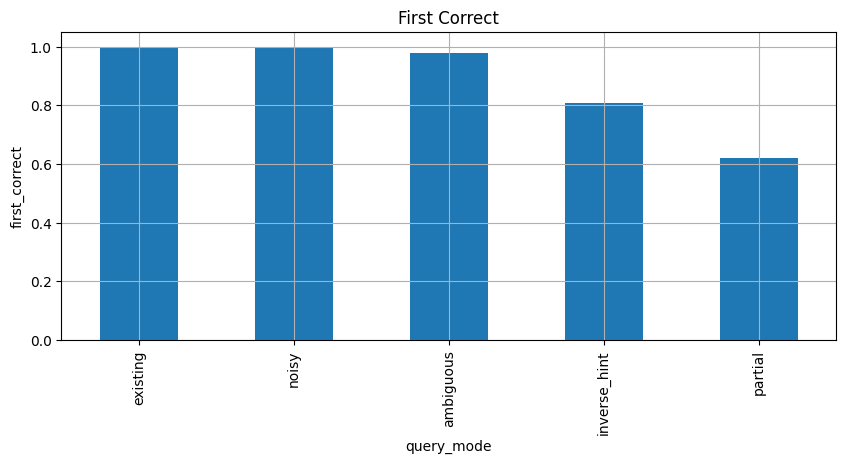

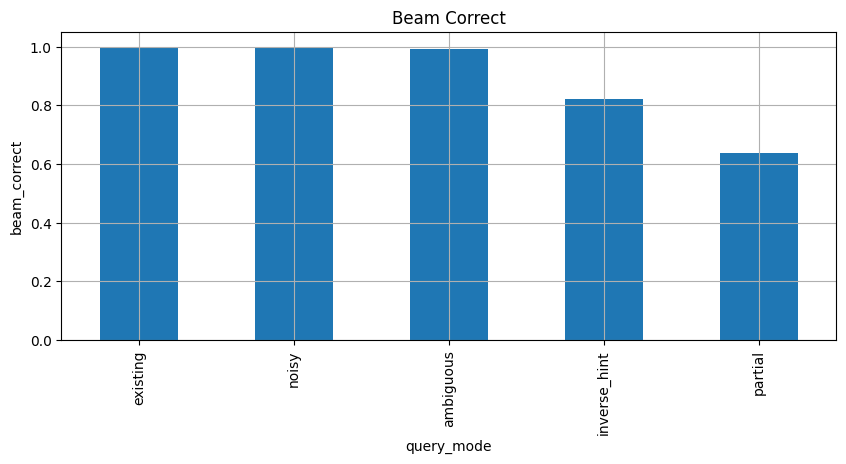

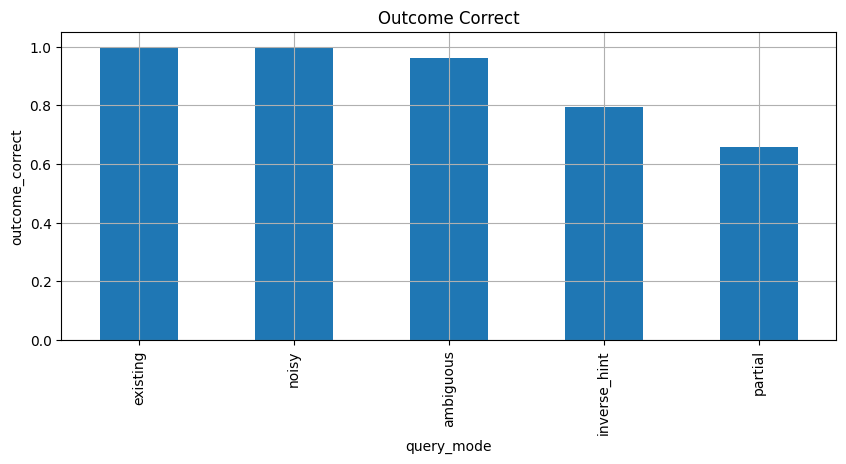

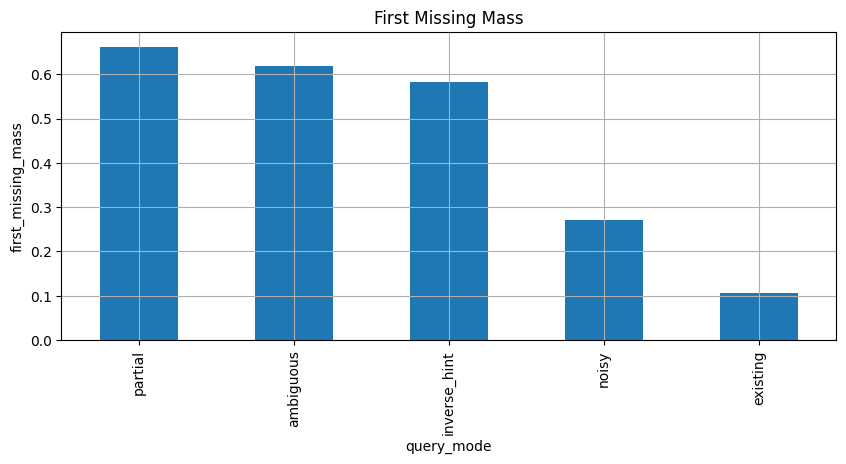

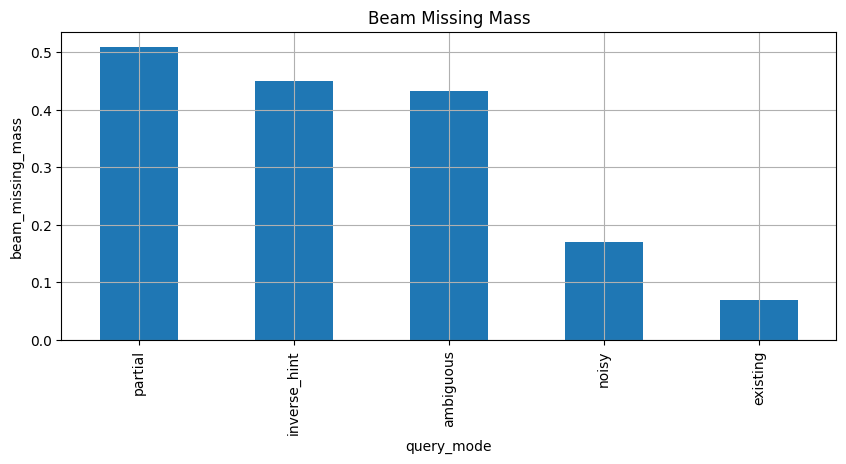

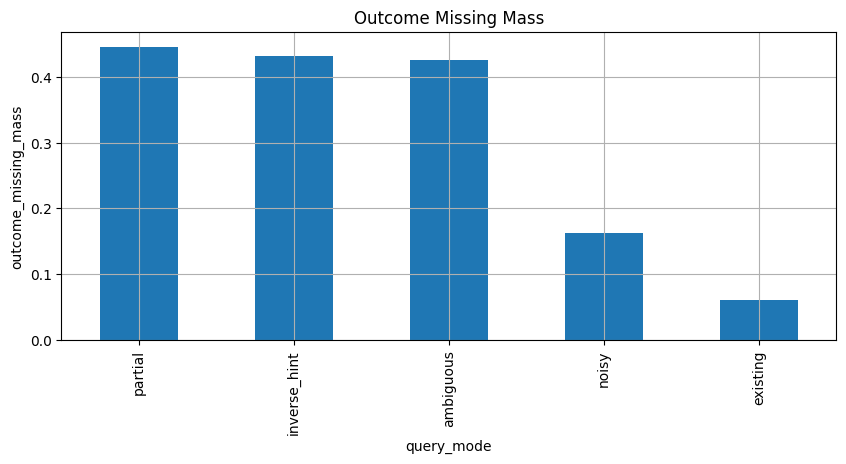

In [18]:

metrics = [
    "first_correct",
    "beam_correct",
    "outcome_correct",
    "first_missing_mass",
    "beam_missing_mass",
    "outcome_missing_mass",
]

for metric in metrics:
    plt.figure(figsize=(10, 4))
    grouped = compare_df.groupby("query_mode")[metric].mean().sort_values(ascending=False)
    grouped.plot(kind="bar")
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("query_mode")
    plt.ylabel(metric)
    plt.show()


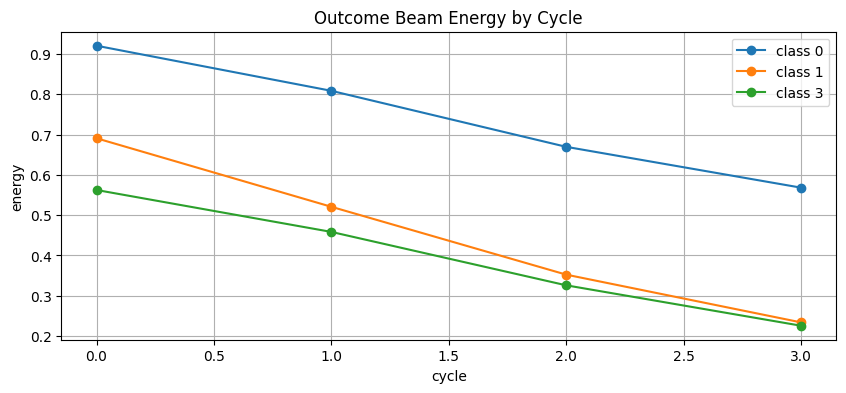

In [19]:

plt.figure(figsize=(10, 4))
for cls in sorted(outcome_trace_df["class"].unique()):
    df = outcome_trace_df[outcome_trace_df["class"] == cls]
    plt.plot(df["cycle"], df["energy"], marker="o", label=f"class {cls}")
plt.title("Outcome Beam Energy by Cycle")
plt.xlabel("cycle")
plt.ylabel("energy")
plt.legend()
plt.show()


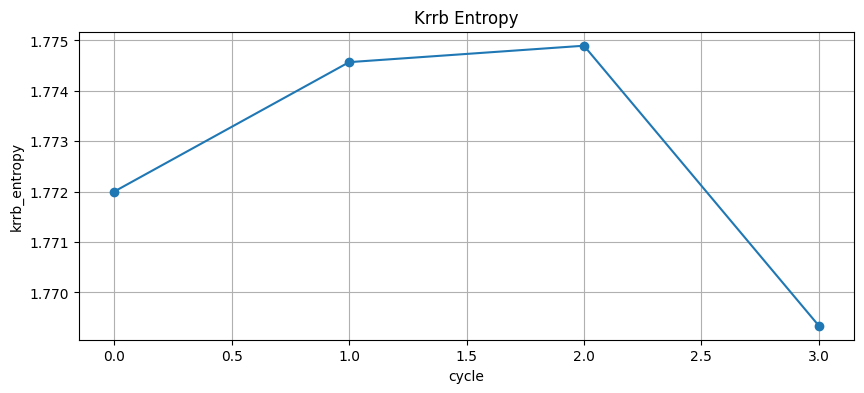

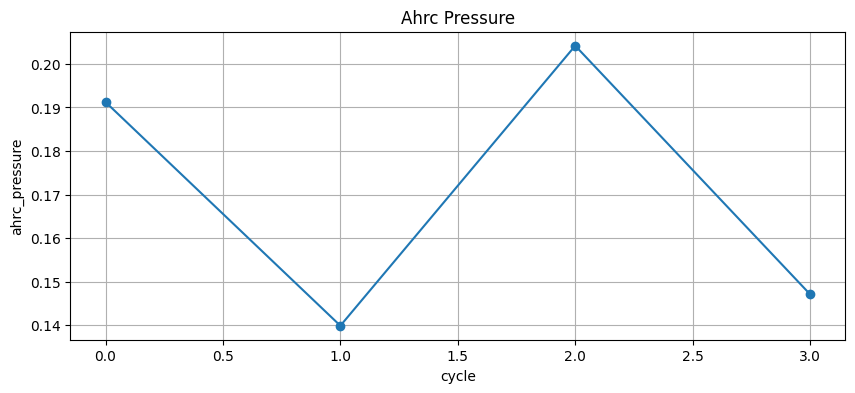

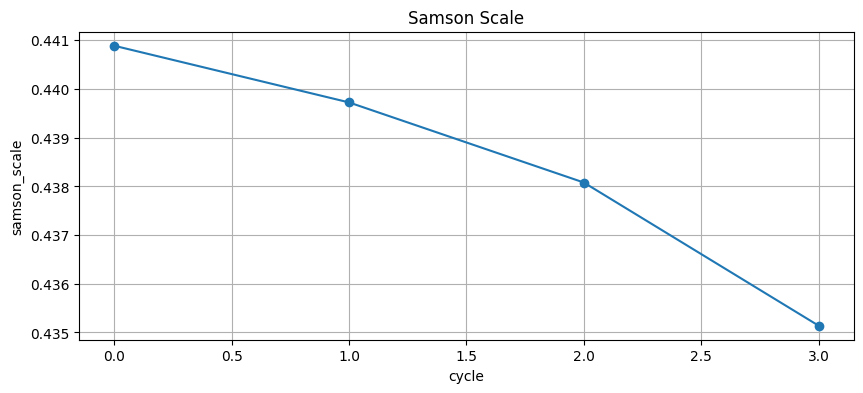

In [20]:

obs_metrics = ["krrb_entropy", "ahrc_pressure", "samson_scale"]

for metric in obs_metrics:
    plt.figure(figsize=(10, 4))
    plt.plot(outcome_trace_df.groupby("cycle")[metric].mean(), marker="o")
    plt.title(metric.replace("_", " ").title())
    plt.xlabel("cycle")
    plt.ylabel(metric)
    plt.show()



## Practical readout

This notebook tests the inversion directly:

- the fold-energy law chooses branches
- KRRB, SILR, Samson, and AHRC are measured as outcomes of the active beam

The first tables to read are:

- `compare_summary`
- `by_mode_compare`
- `partial_summary`
- `observables_summary`
- `outcome_trace_df`

The key question is:
does the system stay strong when the branch laws are observed instead of imposed?
